In [1]:
import scanpy as sc
import seaborn as sns
import pandas as pd
import scar
import matplotlib.pyplot as plt

/home/sofia/miniconda3/envs/defabria/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:


path = "/home/sofia/Projects/etmr/defaria/scRNA/jessa/data/processed/filtered_feature_bc_matrix.h5"
jessa = sc.read_10x_h5(path)
jessa.var_names_make_unique()


path = "/home/sofia/Projects/etmr/defaria/scRNA/jessa/data/raw/raw_feature_bc_matrix.h5"
jessa_raw = sc.read_10x_h5(path)

jessa_raw.var_names_make_unique()



/home/sofia/miniconda3/envs/defabria/lib/python3.13/site-packages/anndata/_core/anndata.py:1794: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/sofia/miniconda3/envs/defabria/lib/python3.13/site-packages/anndata/_core/anndata.py:1794: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/tmp/ipykernel_119889/2886870208.py:3: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`. Example key collisions generated by the make_index_unique algorithm: ['SNORD116-1', 'SNORD116-2', 'SNORD116-3', 'SNORD116-5', 'SNORD116-6']
  jessa.var_names_make_unique()
/home/sofia/miniconda3/envs/defabria/lib/python3.13/site-packages/anndata/_core/anndata.py:1794: User

In [3]:
sc.pp.filter_genes(jessa, min_counts=1)

In [5]:
# mitochondrial genes
jessa.var["mt"] = jessa.var_names.str.startswith("MT-")
# ribosomal genes
jessa.var["ribo"] = jessa.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes.
jessa.var["hb"] = jessa.var_names.str.contains("^HB[^(P)]")

In [6]:
sc.pp.calculate_qc_metrics(jessa, qc_vars=['mt', "ribo", "hb"], percent_top=None, log1p=False, inplace=True)

# --- Subset cells ---
jessa = jessa[
    jessa.obs['n_genes_by_counts'].between(200, 6000) &
    (jessa.obs['total_counts'] < 40000) &
    (jessa.obs['pct_counts_mt'] < 10) ,
    :
].copy()

In [7]:
jessa

AnnData object with n_obs × n_vars = 6576 × 33961
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'genome', 'n_counts', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [8]:
jessa_raw

AnnData object with n_obs × n_vars = 600080 × 57906
    var: 'gene_ids', 'feature_types', 'genome'

In [9]:
from scipy.sparse import issparse

issparse(jessa.X), issparse(jessa_raw.X)

(True, True)

/home/sofia/miniconda3/envs/defabria/lib/python3.13/site-packages/scar/main/_setup.py:103: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  raw_adata.obs["total_counts"] = raw_adata.X.sum(axis=1)
2026-01-16 16:35:02|INFO|setup_anndata|Use all 379233 droplets.
2026-01-16 16:35:03|INFO|setup_anndata|Estimating ambient profile for ['Gene Expression']...
/home/sofia/miniconda3/envs/defabria/lib/python3.13/site-packages/scar/main/_setup.py:154: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  raw_adata.obs["log_prob"] = log_prob
2026-01-16 16:36:31|INFO|setup_anndata|Iteration: 1
2026-01-16 16:37:58|INFO|setup_anndata|Iteration: 2
2026-01-16 16:39:19|INFO|setup_anndata|Iteration: 3
2026-01-16 16:39:19|INFO|setup_anndata|Estimated ambient profile for Gene Expression saved in adata.uns
2026-01-16 16:39:19|INFO|setup_anndata|Estimated ambient profile for all features saved in adata.uns
/

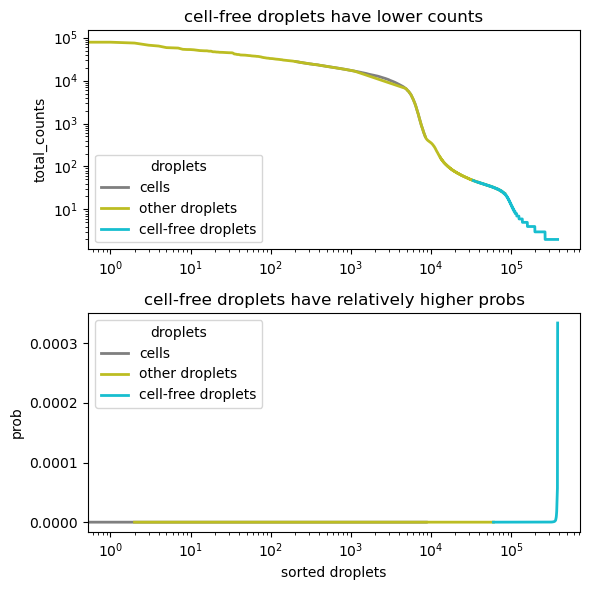

In [10]:
scar.setup_anndata(
    adata = jessa,
    raw_adata = jessa_raw,
    prob = 0.995,
    kneeplot = True
)

In [ ]:
ambient_profile0 = jessa.uns["ambient_profile_Gene Expression"]
ambient_profile0.head()

In [9]:
import torch

torch.utils.collect_env.main()

PyTorch version: 2.9.1+cu128
Is debug build: False
CUDA used to build PyTorch: 12.8
ROCM used to build PyTorch: N/A

OS: Pop!_OS 22.04 LTS (x86_64)
GCC version: (Ubuntu 11.4.0-1ubuntu1~22.04.2) 11.4.0
Clang version: Could not collect
CMake version: Could not collect
Libc version: glibc-2.35

Python version: 3.12.12 | packaged by conda-forge | (main, Oct 22 2025, 23:25:55) [GCC 14.3.0] (64-bit runtime)
Python platform: Linux-6.17.9-76061709-generic-x86_64-with-glibc2.35
Is CUDA available: True
CUDA runtime version: Could not collect
CUDA_MODULE_LOADING set to: 
GPU models and configuration: GPU 0: NVIDIA GeForce GTX 1660
Nvidia driver version: 580.119.02
cuDNN version: Could not collect
Is XPU available: False
HIP runtime version: N/A
MIOpen runtime version: N/A
Is XNNPACK available: True

CPU:
Architecture:                            x86_64
CPU op-mode(s):                          32-bit, 64-bit
Address sizes:                           39 bits physical, 48 bits virtual
Byte Order:     

In [ ]:
jessa_scar = scar.model(raw_count=jessa, # In the case of Anndata object, scar will automatically use the estimated ambient_profile present in adata.uns.
                      ambient_profile=jessa.uns['ambient_profile_Gene Expression'],
                      feature_type='mRNA',
                      sparsity=.7,
                      device='cuda' # CPU, CUDA and MPS are supported.
                     )

jessa_scar.train(epochs=150,
                    batch_size=64,
                    verbose=True
                   )


KeyError: 'ambient_profile_Gene Expression'

: 

,ambient_profile_Gene Expression
WASH7P,0.000003
RP11-34P13.7,0.000000
CICP27,0.000002
AL627309.1,0.000000
RP11-34P13.13,0.000000


In [ ]:
all_droplets = pd.DataFrame(jessa_raw.X.sum(axis=1), index = jessa_raw.obs_names, columns=['total_counts'])

all_droplets['droplets'] = 'cell-free droplets'
all_droplets['droplets'] = all_droplets['droplets'].mask(all_droplets['total_counts']>12, 'droplet II')
all_droplets['droplets'] = all_droplets['droplets'].mask(all_droplets['total_counts']>40, 'droplet I')
all_droplets['droplets'] = all_droplets['droplets'].mask(all_droplets.index.isin(jessa.obs_names), 'cells')
all_droplets = all_droplets.sort_values(by='total_counts', ascending=False).reset_index().rename_axis("rank").reset_index()
all_droplets = all_droplets.loc[all_droplets['total_counts']>0]
all_droplets = all_droplets.set_index('index').rename_axis('cells')

/tmp/ipykernel_2484491/2676078459.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(data = all_droplets,


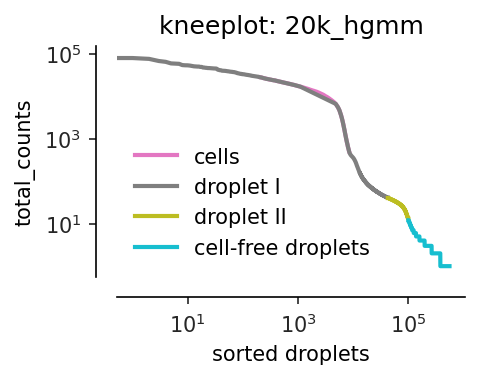

In [ ]:
plt.figure(figsize=(3, 2), dpi=150)

ax = sns.lineplot(data = all_droplets,
                  x='rank',
                  y='total_counts',
                  hue='droplets',
                  hue_order=['cells', 'droplet I', 'droplet II', 'cell-free droplets'],
                  palette=sns.color_palette()[-4:],
                  markers=False,
                  lw=2,
                  ci=None)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('sorted droplets');
ax.legend(loc='lower left', ncol=1, title=None, frameon=False)
ax.set_title(f'kneeplot: 20k_hgmm')

sns.set_palette("muted")
sns.set_style("ticks")
sns.despine(offset=10, trim=False);

In [ ]:
cell_free = jessa_raw[jessa_raw.obs_names.isin(all_droplets[all_droplets['droplets']=='cell-free droplets'].index)]

cell_free = cell_free[:, jessa.var_names]

# average and normalize the transcript in cell-free droplets.
ambient_profile1 = pd.DataFrame((cell_free.X.sum(axis=0)/cell_free.X.sum()).A1, index = jessa.var_names, columns = ['ambient profile'])

ambient_profile1.head()

,ambient profile
WASH7P,0.000005
RP11-34P13.7,0.000000
CICP27,0.000002
AL627309.1,0.000000
RP11-34P13.13,0.000000


In [ ]:
from sklearn.metrics import r2_score

r2_score(ambient_profile0, ambient_profile1)

0.9898292676424474

NameError: name 'scar' is not defined